Uniform grid computed in 0.00 seconds
Splitting grid computed in 0.11 seconds
Trying c=20.0000 (error=inf)
Trying c=10.0000 (error=192.131518)
Trying c=5.0000 (error=192.131518)
Trying c=2.5000 (error=192.131518)
Trying c=1.2500 (error=32.200329)
Trying c=0.6250 (error=32.200329)
Trying c=0.3125 (error=32.200329)
Trying c=0.1562 (error=19.167903)
Trying c=0.0781 (error=19.167903)
Trying c=0.0391 (error=5.846674)
Trying c=0.0195 (error=1.914015)
Trying c=0.0098 (error=0.615969)
Trying c=0.0049 (error=0.529937)
Trying c=0.0024 (error=0.283083)
Trying c=0.0037 (error=0.044066)
Trying c=0.0031 (error=0.044066)
Trying c=0.0027 (error=0.044066)
Trying c=0.0026 (error=0.044066)
Trying c=0.0025 (error=0.044066)
Trying c=0.0025 (error=0.044066)
Trying c=0.0025 (error=0.044066)
Trying c=0.0025 (error=0.044066)
Trying c=0.0025 (error=0.044066)
Trying c=0.0025 (error=0.042557)
Trying c=0.0025 (error=0.042557)
Trying c=0.0025 (error=0.042557)
Trying c=0.0025 (error=0.004739)
Trying c=0.0025 (error=

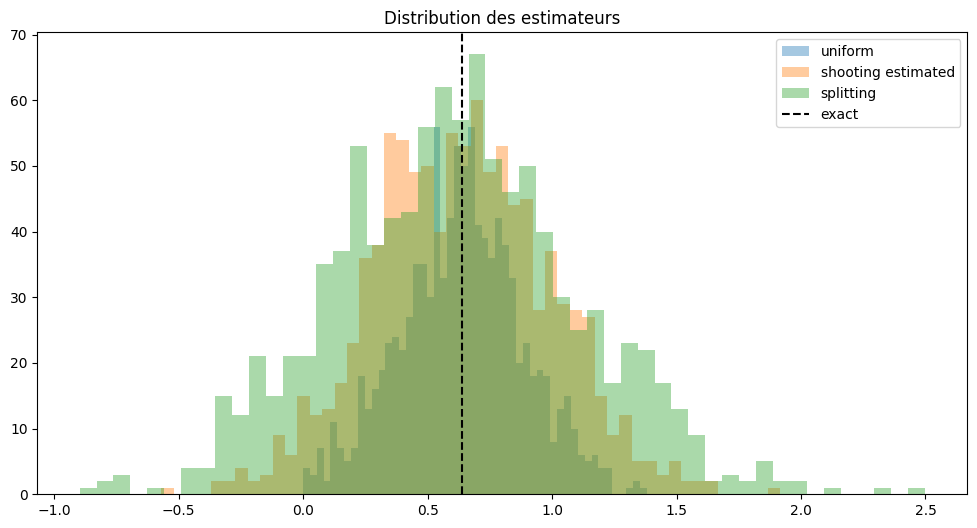

Variance uniform      : 0.05998967723030001
Variance estimated    : 0.12606077280632505
Variance splitting    : 0.24339249843871297


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# =========================
# Paramètres
# =========================
L = 50
n_per_bin = 1
n_trials = 1000

# =========================
# Fonctions
# =========================
f = lambda l: np.sin(np.pi * l)

#sigma2 = lambda l: np.abs(np.sin(np.pi * l))
sigma2 = lambda l: 0.1 + (1 + 10*l**2) * (np.sin(8*np.pi*l)**2 + 0.2)
#sigma2 = lambda l: np.abs(np.cos(np.pi * l)) # pour avoir une variance plus marquée 
#sigma2 = lambda l: 0.05 + (np.sin(1/(l+0.01))**2)



# =========================
# Estimation locale de variance
# =========================
def estimate_sigma2(l, eps=0.02, n_samples=20):
    a = max(0.0, l - eps)
    b = min(1.0, l + eps)
    
    x = np.random.uniform(l, b, n_samples)
    y = f(x) + np.random.normal(0, np.sqrt(sigma2(x)))
    
    # enlever le biais de f
    return np.var(y)

# =========================
# Nadaraya-Watson
# =========================
def nadaraya_watson(lam0, lam_samples, y_samples, h):
    weights = np.exp(-((lam_samples - lam0)**2) / (2*h**2))
    weights /= np.sum(weights)
    return np.sum(weights * y_samples)

# =========================
# Estimation Var(E[Y|λ])
# =========================
def estimate_var_conditional(lam0, eps=0.05, n_samples=20):
    lam = np.random.uniform(max(0, lam0-eps), min(1, lam0+eps), n_samples)
    
    y = f(lam) + np.random.normal(0, np.sqrt(sigma2(lam)))
    
    h = eps / 2
    f_hat = np.array([nadaraya_watson(li, lam, y, h) for li in lam])
    
    return max(np.var(f_hat), 1e-8)  # éviter division par zéro

# =========================
# Shooting avec variance NW
# =================


# =========================
def shooting_grid_L_points(L, eps=0.02, tol=1e-6, maxiter=100):
    """
    Retourne une grille de L points dans [0,1] avec l'erreur finale minimisée.
    """
    cmin, cmax = 0.0, 40.0
    best_lam = None
    best_error = np.inf

    for _ in range(maxiter):
        c = (cmin + cmax) / 2.0
        print(f"Trying c={c:.4f} (error={best_error:.6f})")
        
        lam = [0.0]
        
        # construire exactement L points
        while len(lam) < L:
            var_est = estimate_var_conditional(lam[-1], eps)
            var_est = max(var_est, 1e-8)
            next_lam = lam[-1] + c / np.sqrt(var_est)
            lam.append(next_lam)
        
        lam = np.array(lam)
        error = abs(lam[-1] - 1.0)
        
        if error < best_error:
            best_error = error
            best_lam = lam.copy()
        
        # ajustement dichotomique
        if lam[-1] < 1.0:
            cmin = c
        else:
            cmax = c
        
        if error < tol:
            break

    # ajustement final pour que le dernier point soit exactement 1
    best_lam[-1] = 1.0
    
    return best_lam



# =========================
# Splitting adaptatif
# =========================
import numpy as np

def bin_variance(l0, l1, n_samples=20):
    lam = np.random.uniform(l0, l1, n_samples)
    y = f(lam) + np.random.normal(0, np.sqrt(sigma2(lam)))
    return np.var(y)

def splitting_grid(L, initial_bins=10):
    """
    Construire une grid greedy à partir d'une grid uniform initiale.
    
    Parameters:
    - L : nombre final de bins
    - initial_bins : nombre initial de bins uniformes
    """
    # Créer une grid initiale uniforme
    uniform_grid = np.linspace(0.0, 1.0, initial_bins + 1)
    bins = [(uniform_grid[i], uniform_grid[i+1]) for i in range(initial_bins)]
    
    # Greedy split jusqu'à obtenir L bins
    while len(bins) < L:
        # Calculer la variance de chaque bin
        vars_ = [bin_variance(a, b) for (a, b) in bins]
        # Choisir le bin avec variance maximale
        idx = np.argmax(vars_)
        a, b = bins[idx]
        mid = 0.5 * (a + b)
        # Remplacer le bin par ses deux moitiés
        bins.pop(idx)
        bins.insert(idx, (a, mid))
        bins.insert(idx + 1, (mid, b))
    
    # Construire la grid finale
    grid = [bins[0][0]]  # commencer par la borne inférieure du premier bin
    for (_, b) in bins:
        grid.append(b)
    return np.array(grid)

# =========================
# Grilles
# =========================
t0 = time.perf_counter()
grid_uniform = np.linspace(0,1,L+1)
t_uniform = time.perf_counter() - t0
print(f"Uniform grid computed in {t_uniform:.2f} seconds")
t0 = time.perf_counter()
grid_split = splitting_grid(L)
t_split = time.perf_counter() - t0
print(f"Splitting grid computed in {t_split:.2f} seconds")
t0 = time.perf_counter()
grid_est = shooting_grid_L_points(L=L, eps=0.02, tol=1e-6, maxiter=50)
t_shoot = time.perf_counter() - t0
print(f"Shooting grid computed in {t_shoot:.2f} seconds")

# =========================
# Estimateur stratifié
# =========================
def stratified_estimator(grid):
    L = len(grid)-1
    est = 0.0
    for l in range(L):
        a, b = grid[l], grid[l+1]
        lam = np.random.uniform(a, b, n_per_bin)
        y = f(lam) + np.random.normal(0, np.sqrt(sigma2(lam)))
        est += (b-a) * np.mean(y)
    return est
##
# =========================
# Simulations
# =========================
est_uniform = np.array([stratified_estimator(grid_uniform) for _ in range(n_trials)])
est_split   = np.array([stratified_estimator(grid_split) for _ in range(n_trials)])
est_est     = np.array([stratified_estimator(grid_est) for _ in range(n_trials)])
exact = 2/np.pi

# =========================
# 📊 PLOTS
# =========================

# Histogrammes
plt.figure(figsize=(12,6))
plt.hist(est_uniform, bins=50, alpha=0.4, label="uniform")
plt.hist(est_est, bins=50, alpha=0.4, label="shooting estimated")
plt.hist(est_split, bins=50, alpha=0.4, label="splitting")
plt.axvline(exact, color='black', linestyle='--', label="exact")
plt.legend()
plt.title("Distribution des estimateurs")
plt.show()

# Variances
print("Variance uniform      :", np.var(est_uniform))
print("Variance estimated    :", np.var(est_est))
print("Variance splitting    :", np.var(est_split))

## spliting method

Splitting grid computed in 0.04 seconds
Trying c=10.0000 (error=inf)
Trying c=5.0000 (error=1369.473351)
Trying c=2.5000 (error=260.597195)
Trying c=1.2500 (error=108.059707)
Trying c=0.6250 (error=108.059707)
Trying c=0.3125 (error=108.059707)
Trying c=0.1562 (error=20.193250)
Trying c=0.0781 (error=7.810172)
Trying c=0.0391 (error=2.242779)
Trying c=0.0195 (error=2.242779)
Trying c=0.0098 (error=1.145910)
Trying c=0.0049 (error=0.754257)
Trying c=0.0024 (error=0.273496)
Trying c=0.0012 (error=0.168889)
Trying c=0.0018 (error=0.168889)
Trying c=0.0021 (error=0.014069)
Trying c=0.0020 (error=0.014069)
Trying c=0.0019 (error=0.014069)
Trying c=0.0019 (error=0.000987)
Trying c=0.0019 (error=0.000987)
Trying c=0.0019 (error=0.000987)
Trying c=0.0019 (error=0.000987)
Trying c=0.0019 (error=0.000987)
Trying c=0.0019 (error=0.000987)
Trying c=0.0019 (error=0.000987)
Trying c=0.0019 (error=0.000987)
Trying c=0.0019 (error=0.000987)
Trying c=0.0019 (error=0.000987)
Trying c=0.0019 (error=0.000

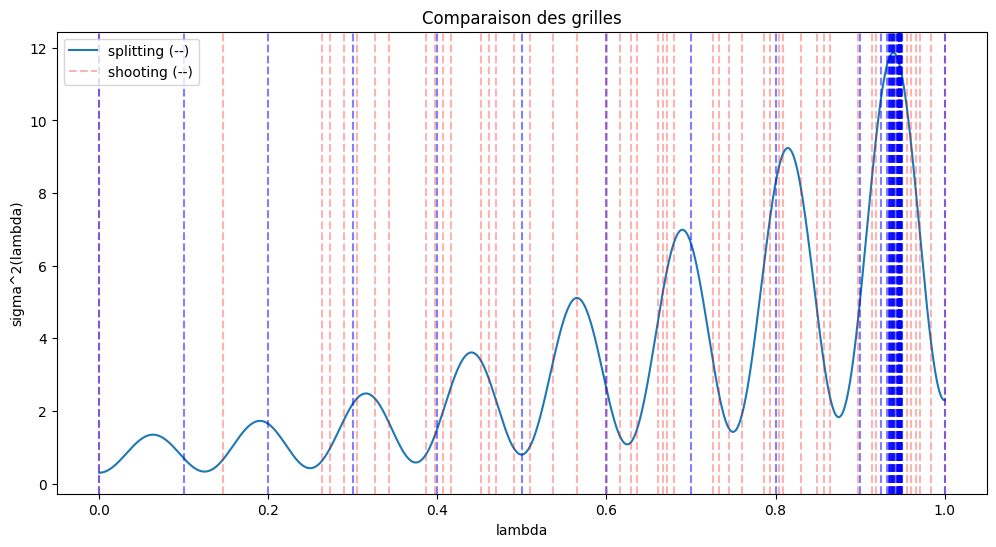

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import time


# =========================
def nadaraya_watson(lam0, lam_samples, y_samples, h):
    weights = np.exp(-((lam_samples - lam0)**2) / (2*h**2))
    weights /= np.sum(weights)
    return np.sum(weights * y_samples)

# =========================
def estimate_var_conditional(lam0, eps=0.05, n_samples=50):
    lam = np.random.uniform(max(0, lam0-eps), min(1, lam0+eps), n_samples)
    y = f(lam) + np.random.normal(0, np.sqrt(sigma2(lam)))
    h = eps / 2
    f_hat = np.array([nadaraya_watson(li, lam, y, h) for li in lam])
    return max(np.var(f_hat), 1e-8)  # éviter division par zéro

# =========================
def shooting_grid_L_points(L=20, eps=0.02, tol=1e-6, maxiter=50):
    """
    Retourne une grille de L points dans [0,1] avec l'erreur finale minimisée.
    """
    cmin, cmax = 0.0, 20.0
    best_lam = None
    best_error = np.inf

    for _ in range(maxiter):
        c = (cmin + cmax) / 2.0
        print(f"Trying c={c:.4f} (error={best_error:.6f})")
        
        lam = [0.0]
        
        # construire exactement L points
        while len(lam) < L:
            var_est = estimate_var_conditional(lam[-1], eps)
            var_est = max(var_est, 1e-8)
            next_lam = lam[-1] + c / np.sqrt(var_est)
            lam.append(next_lam)
        
        lam = np.array(lam)
        error = abs(lam[-1] - 1.0)
        
        if error < best_error:
            best_error = error
            best_lam = lam.copy()
        
        # ajustement dichotomique
        if lam[-1] < 1.0:
            cmin = c
        else:
            cmax = c
        
        if error < tol:
            break

    # ajustement final pour que le dernier point soit exactement 1
    best_lam[-1] = 1.0
    
    return best_lam

# =========================
# Splitting adaptatif
# =========================
def bin_variance(l0, l1, n_samples=50):
    lam = np.random.uniform(l0, l1, n_samples)
    y = f(lam) + np.random.normal(0, np.sqrt(sigma2(lam)))
    return np.var(y)

import numpy as np

def bin_variance(l0, l1, n_samples=20):
    lam = np.random.uniform(l0, l1, n_samples)
    y = f(lam) + np.random.normal(0, np.sqrt(sigma2(lam)))
    return np.var(y)

def splitting_grid(L, initial_bins=10):
    """
    Construire une grid greedy à partir d'une grid uniform initiale.
    
    Parameters:
    - L : nombre final de bins
    - initial_bins : nombre initial de bins uniformes
    """
    # Créer une grid initiale uniforme
    uniform_grid = np.linspace(0.0, 1.0, initial_bins + 1)
    bins = [(uniform_grid[i], uniform_grid[i+1]) for i in range(initial_bins)]
    
    # Greedy split jusqu'à obtenir L bins
    while len(bins) < L:
        # Calculer la variance de chaque bin
        vars_ = [bin_variance(a, b) for (a, b) in bins]
        # Choisir le bin avec variance maximale
        idx = np.argmax(vars_)
        a, b = bins[idx]
        mid = 0.5 * (a + b)
        # Remplacer le bin par ses deux moitiés
        bins.pop(idx)
        bins.insert(idx, (a, mid))
        bins.insert(idx + 1, (mid, b))
    
    # Construire la grid finale
    grid = [bins[0][0]]  # commencer par la borne inférieure du premier bin
    for (_, b) in bins:
        grid.append(b)
    return np.array(grid)

# =========================
# Grilles
# =========================
t0 = time.perf_counter()
grid_split = splitting_grid(L)
t_split = time.perf_counter() - t0
print(f"Splitting grid computed in {t_split:.2f} seconds")
t0 = time.perf_counter()
grid_est = shooting_grid_L_points(L=L, eps=0.02, tol=1e-6, maxiter=50)
t_shoot = time.perf_counter() - t0
print(f"Shooting grid computed in {t_shoot:.2f} seconds")


# =========================
# Plot comparaison
# =========================
l = np.linspace(0,1,1000)
y = sigma2(l)

plt.figure(figsize=(12,6))
plt.plot(l, y, label="sigma^2(lambda)")

# shooting
for lam in grid_est:
    plt.axvline(lam, linestyle='--', alpha=0.3, color='red')

# splitting
for lam in grid_split:
   plt.axvline(lam, linestyle='--', alpha=0.5, color='blue')


plt.title("Comparaison des grilles")
plt.xlabel("lambda")
plt.ylabel("sigma^2(lambda)")
plt.legend(["splitting (--)", "shooting (--)"])
plt.show()